In [1]:
import numpy as np

from utils.data_utils import load_data, split_data
from utils.visualizer import *
from machines.random_forest import evaluate_random_forest
    
system_types = ['3PD', '3Chaos']
# ['1B', '1OSC', '1SSS', '1Bosc', '2OSC', '2SSS', '2QP', '3OSC', '3SSS', '3PD', '3Chaos']
V = np.inf; # 10**5 10**8 np.inf
max_samples = 100
data, labels, beta_epsilon_pairs = load_data(system_types, V, max_samples)
train_data, test_data, train_labels, test_labels, train_pairs , test_pairs = split_data(data, labels, beta_epsilon_pairs, option="option2", balanced=True)

Fitting 3 folds for each of 216 candidates, totalling 648 fits
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=4, min_samples_split=2, n_estimators=100; total time=   8.5s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=2, min_samples_split=5, n_estimators=100; total time=   8.7s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=4, min_samples_split=5, n_estimators=100; total time=   8.7s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=10, n_estimators=100; total time=   8.8s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=2, min_samples_split=5, n_estimators=100; total time=   8.9s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=   8.9s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=2, min_samples_split=2, n_estimators=100; total time=   9.0s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=2, min_samples_split=

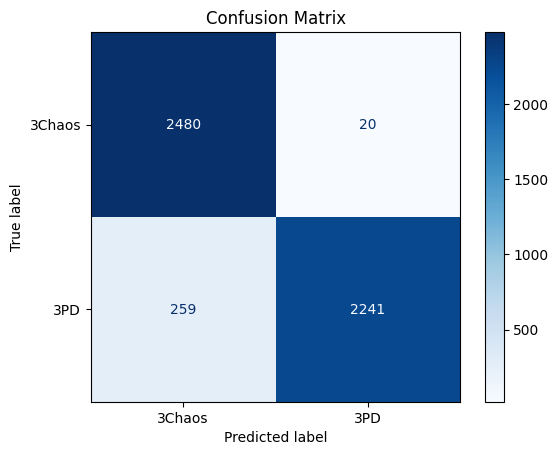

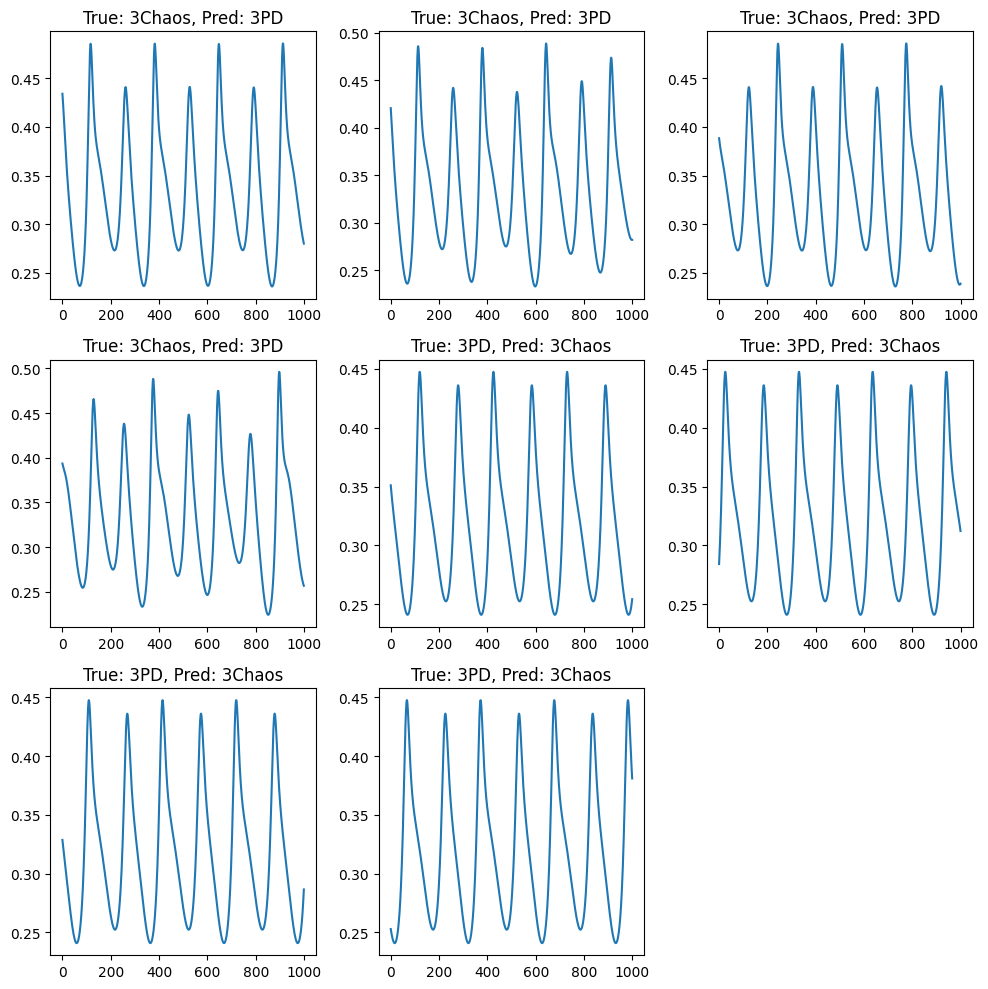

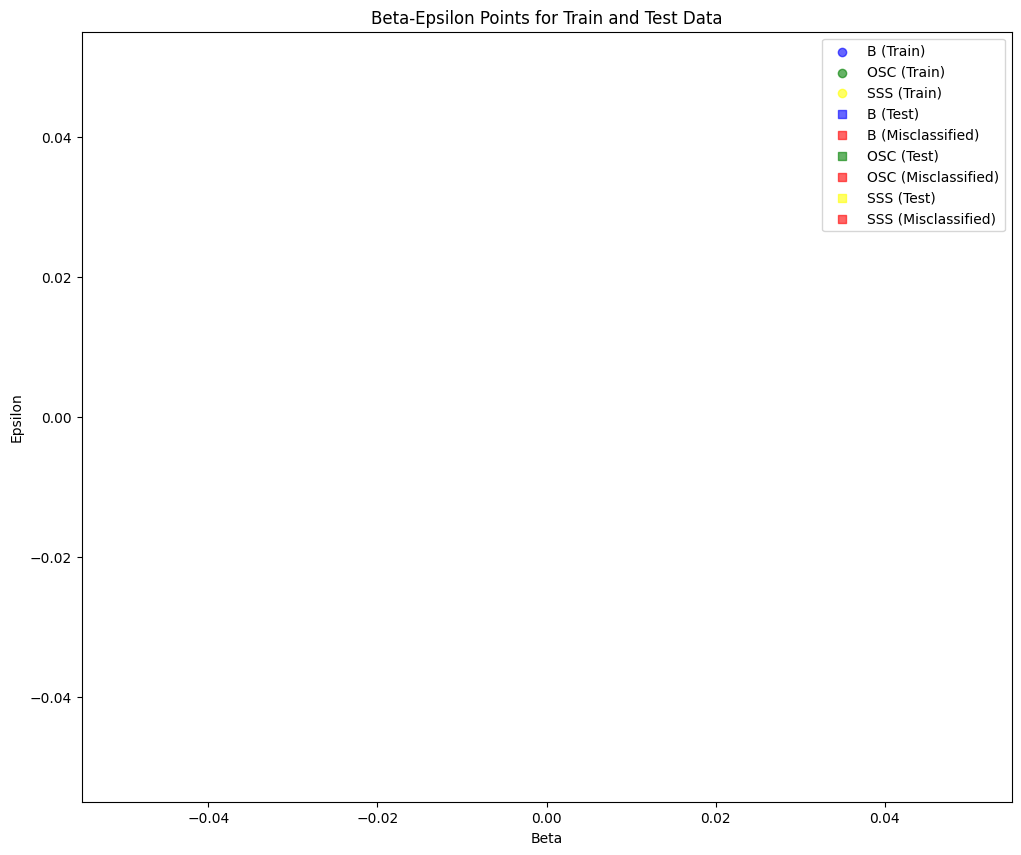

In [2]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
import numpy as np

def evaluate_random_forest_with_grid_search(train_data, train_labels, test_data, test_labels, random_state=1000):
    param_grid = {
        'n_estimators': [100, 200, 300],
        'max_depth': [None, 10, 20, 30],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'max_features': ['sqrt', 'log2']
    }
    
    # RandomForestClassifier 객체 생성
    rf = RandomForestClassifier(random_state=random_state)
    
    # GridSearchCV 설정
    grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=3, n_jobs=-1, verbose=2)
    grid_search.fit(train_data, train_labels)
    
    # 최적의 파라미터로 모델 생성
    best_rf = grid_search.best_estimator_
    
    # 예측 및 혼동 행렬 계산
    predictions = best_rf.predict(test_data)
    cm = confusion_matrix(test_labels, predictions)
    
    return cm, best_rf, predictions

# Evaluate model with parameter search
cm, clf, predictions = evaluate_random_forest_with_grid_search(train_data, train_labels, test_data, test_labels, random_state=1000)

# Visualization
plot_confusion_matrix(cm, 'Confusion Matrix', labels=np.unique(train_labels))
visualize_misclassified(test_data, test_labels, predictions)
visualize_beta_epsilon_points(train_labels, test_labels, train_pairs, test_pairs, predictions)

# Train and test pairs intersection
overlap = np.intersect1d(train_pairs, test_pairs)
